# Dask - E-commerce Business Transaction

En esta sección se procesará el dataset de transacciones de comercio electrónico utilizando Dask DataFrame.

## Instalación de dependencias

In [1]:
!pip install -q "dask[dataframe]" kagglehub graphviz

In [2]:
from pathlib import Path
import time

import dask.dataframe as dd
import numpy as np
import pandas as pd

## Descarga del dataset

In [3]:
import kagglehub

DATASET_DIR = Path.cwd().parent / "dataset"
LOCAL_FILE = DATASET_DIR / "sales_transaction.csv"

if not LOCAL_FILE.exists():
    cached = Path(kagglehub.dataset_download("gabrielramos87/an-online-shop-business"))
    DATASET_DIR.mkdir(parents=True, exist_ok=True)
    LOCAL_FILE.write_bytes((cached / "Sales Transaction v.4a.csv").read_bytes())
    print(f"Dataset descargado en: {LOCAL_FILE}")
else:
    print(f"Dataset ya disponible: {LOCAL_FILE}")

Dataset ya disponible: /home/bricafio/Escritorio/BigData/dataset/sales_transaction.csv


## Lectura distribuida

In [4]:
ddf = dd.read_csv(
    LOCAL_FILE,
    blocksize="1MB",
    dtype={"TransactionNo": "string", "ProductNo": "string", "CustomerNo": "string"},
    na_values=["NA"],
    assume_missing=True,
)
print(f"Dimensiones: {ddf.shape[0].compute():,} filas x {len(ddf.columns)} columnas")

In [5]:
print("Número de particiones:", ddf.npartitions)

Número de particiones: 42


## Inspección de las particiones

In [6]:
ddf.get_partition(0).head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12.0,17490,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36.0,13069,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12.0,13069,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12.0,13069,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6.0,13069,United Kingdom


In [7]:
ddf.get_partition(1).head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,580610,12/5/2019,22992,Revolver Wooden Ruler,7.24,2.0,12610,United Kingdom
1,580610,12/5/2019,22993,Set Of 4 Pantry Jelly Moulds,7.24,1.0,12610,United Kingdom
2,580610,12/5/2019,23040,Paper Lantern 9 Point Snow Star,7.67,3.0,12610,United Kingdom
3,580610,12/5/2019,23040,Paper Lantern 9 Point Snow Star,6.13,4.0,12610,United Kingdom
4,580610,12/5/2019,23042,Paper Lantern 7 Point Snow Star,6.13,2.0,12610,United Kingdom


In [8]:
# Visualizamos la última partición

ultima_particion = ddf.npartitions - 1

print("Última partición:", ultima_particion)

Última partición: 41


In [9]:
ddf.get_partition(ultima_particion).tail()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
12749,C536548,12/1/2018,22168,Organiser Wood Antique White,18.96,-2.0,12472,Germany
12750,C536548,12/1/2018,21218,Red Spotty Biscuit Tin,14.09,-3.0,12472,Germany
12751,C536548,12/1/2018,20957,Porcelain Hanging Bell Small,11.74,-1.0,12472,Germany
12752,C536548,12/1/2018,22580,Advent Calendar Gingham Sack,16.35,-4.0,12472,Germany
12753,C536548,12/1/2018,22767,Triple Photo Frame Cornice,20.45,-2.0,12472,Germany


## Realizamos una pequeña exploración inicial de los datos

In [10]:
# Vemos los tipos de datos
print(ddf.dtypes)

TransactionNo    string[pyarrow]
Date             string[pyarrow]
ProductNo        string[pyarrow]
ProductName      string[pyarrow]
Price                    float64
Quantity                 float64
CustomerNo       string[pyarrow]
Country          string[pyarrow]
dtype: object


In [11]:
# Vemos las columnas
print(ddf.columns)

Index(['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Price',
       'Quantity', 'CustomerNo', 'Country'],
      dtype='object')


In [12]:
# El número de columnas
n_cols = len(ddf.columns)

print("Número de columnas:", n_cols)

Número de columnas: 8


In [13]:
# El número de registros

start = time.perf_counter()

n_rows = ddf.shape[0].compute()

elapsed = time.perf_counter() - start

print(f"Número de registros: {n_rows:,}")
print(f"Tiempo: {elapsed:.4f} segundos")

Número de registros: 536,350
Tiempo: 1.4263 segundos


In [14]:
# Y la cantidad de valores nulos por columna

start = time.perf_counter()

missing = ddf.isnull().sum().compute()

elapsed = time.perf_counter() - start

print("Valores nulos por columna:")
print(missing)

print(f"\nTiempo: {elapsed:.4f} segundos")

Valores nulos por columna:
TransactionNo     0
Date              0
ProductNo         0
ProductName       0
Price             0
Quantity          0
CustomerNo       55
Country           0
dtype: int64

Tiempo: 3.8303 segundos


## Consultas

### Consulta 1 : Identificación y eliminación de valores nulos
Rubro : Limpieza de datos

In [15]:
ddf = ddf.dropna(subset=["CustomerNo"])

In [16]:
# Todavia no se ejecuto el procesamiento
print(ddf)

Dask DataFrame Structure:
               TransactionNo    Date ProductNo ProductName    Price Quantity CustomerNo Country
npartitions=42                                                                                 
                      string  string    string      string  float64  float64     string  string
                         ...     ...       ...         ...      ...      ...        ...     ...
...                      ...     ...       ...         ...      ...      ...        ...     ...
                         ...     ...       ...         ...      ...      ...        ...     ...
                         ...     ...       ...         ...      ...      ...        ...     ...
Dask Name: dropna, 3 expressions
Expr=DropnaFrame(frame=ArrowStringConversion(frame=FromMapProjectable(f6dd460)), subset=['CustomerNo'])


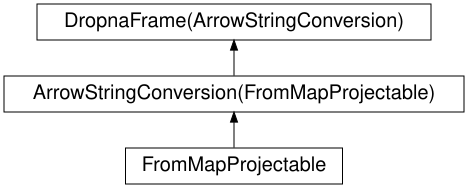

In [17]:
ddf.visualize()

In [18]:
print("Registros después de eliminar nulos:",ddf.shape[0].compute())

Registros después de eliminar nulos: 536295


### Consulta 2 : Eliminación de duplicados
Rubro : Deduplicación

In [19]:
filas_antes = ddf.shape[0].compute()

print(f"Registros antes de eliminar duplicados: {filas_antes:,}")

ddf = ddf.drop_duplicates()

filas_despues = ddf.shape[0].compute()

duplicados_eliminados = filas_antes - filas_despues

print(f"Duplicados eliminados: {duplicados_eliminados:,}")
print(f"Registros después de eliminar duplicados: {filas_despues:,}")

Registros antes de eliminar duplicados: 536,295


Duplicados eliminados: 5,200
Registros después de eliminar duplicados: 531,095


### Consulta 3 : Transformación de fechas
Rubro: Transformación de variables

In [20]:
ddf["Date"] = dd.to_datetime(ddf["Date"],dayfirst=False,errors="coerce")

In [21]:
ddf["Año"] = ddf["Date"].dt.year
ddf["Mes"] = ddf["Date"].dt.month
ddf["Día"] = ddf["Date"].dt.day

In [22]:
# Verificamos
ddf[["Date", "Año", "Mes", "Día"]].head(10)

,Date,Año,Mes,Día
39,2019-12-09,2019,12,9
70,2019-12-09,2019,12,9
206,2019-12-09,2019,12,9
263,2019-12-09,2019,12,9
303,2019-12-09,2019,12,9
336,2019-12-09,2019,12,9
341,2019-12-09,2019,12,9
373,2019-12-09,2019,12,9
429,2019-12-09,2019,12,9
437,2019-12-09,2019,12,9


### Consulta 4 : Creamos TotalSales
Rubro : Transformación de variables

In [23]:
ddf["TotalSales"] = (ddf["Price"] * ddf["Quantity"])

In [24]:
ddf[["Price", "Quantity", "TotalSales"]].head(10)

,Price,Quantity,TotalSales
39,11.53,24.0,276.72
70,11.53,20.0,230.60
206,6.19,1.0,6.19
263,6.19,2.0,12.38
303,6.19,1.0,6.19
336,6.19,1.0,6.19
341,6.19,2.0,12.38
373,6.19,2.0,12.38
429,6.19,2.0,12.38
437,6.19,1.0,6.19


### Consulta 5 : Filtrado de transacciones válidas
Rubro : Filtrado

In [25]:
transacciones_validas = ((ddf["Quantity"] >= 0) &(~ddf["TransactionNo"].str.startswith("C", na=False)))

ddf = ddf[transacciones_validas]

In [26]:
# Verificamos si se filtro correctamente

cantidades_negativas = ((ddf["Quantity"] < 0).sum().compute())

cancelaciones = (ddf["TransactionNo"].str.startswith("C", na=False).sum().compute())

In [27]:
print("Cantidades negativas:", cantidades_negativas)
print("Cancelaciones:", cancelaciones)

Cantidades negativas: 0
Cancelaciones: 0


### Consulta 6 : Facturación mensual
Rubro : Agrupación y agregación

In [28]:
facturacion_mensual = (ddf.groupby(["Año", "Mes"])["TotalSales"].sum())

In [29]:
facturacion_mensual

Dask Series Structure:
npartitions=1
    float64
        ...
Dask Name: sum, 29 expressions
Expr=Sum(frame=(Filter(frame=Assign(frame=Assign(frame=Assign(frame=Assign(frame=Assign(frame=DropDuplicates(frame=DropnaFrame(frame=ArrowStringConversion(frame=FromMapProjectable(f6dd460)), subset=['CustomerNo']))))))), predicate=(Assign(frame=Assign(frame=Assign(frame=Assign(frame=Assign(frame=DropDuplicates(frame=DropnaFrame(frame=ArrowStringConversion(frame=FromMapProjectable(f6dd460)), subset=['CustomerNo']))))))))['Quantity'] >= 0 & ~ FunctionMap(frame=(Assign(frame=Assign(frame=Assign(frame=Assign(frame=Assign(frame=DropDuplicates(frame=DropnaFrame(frame=ArrowStringConversion(frame=FromMapProjectable(f6dd460)), subset=['CustomerNo']))))))))['TransactionNo'], accessor='str', attr='startswith', args=('C',), kwargs={'na': False})))[['Año', 'Mes', 'TotalSales']], observed=False, chunk_kwargs={'numeric_only': False}, aggregate_kwargs={'numeric_only': False}, _slice='TotalSales')

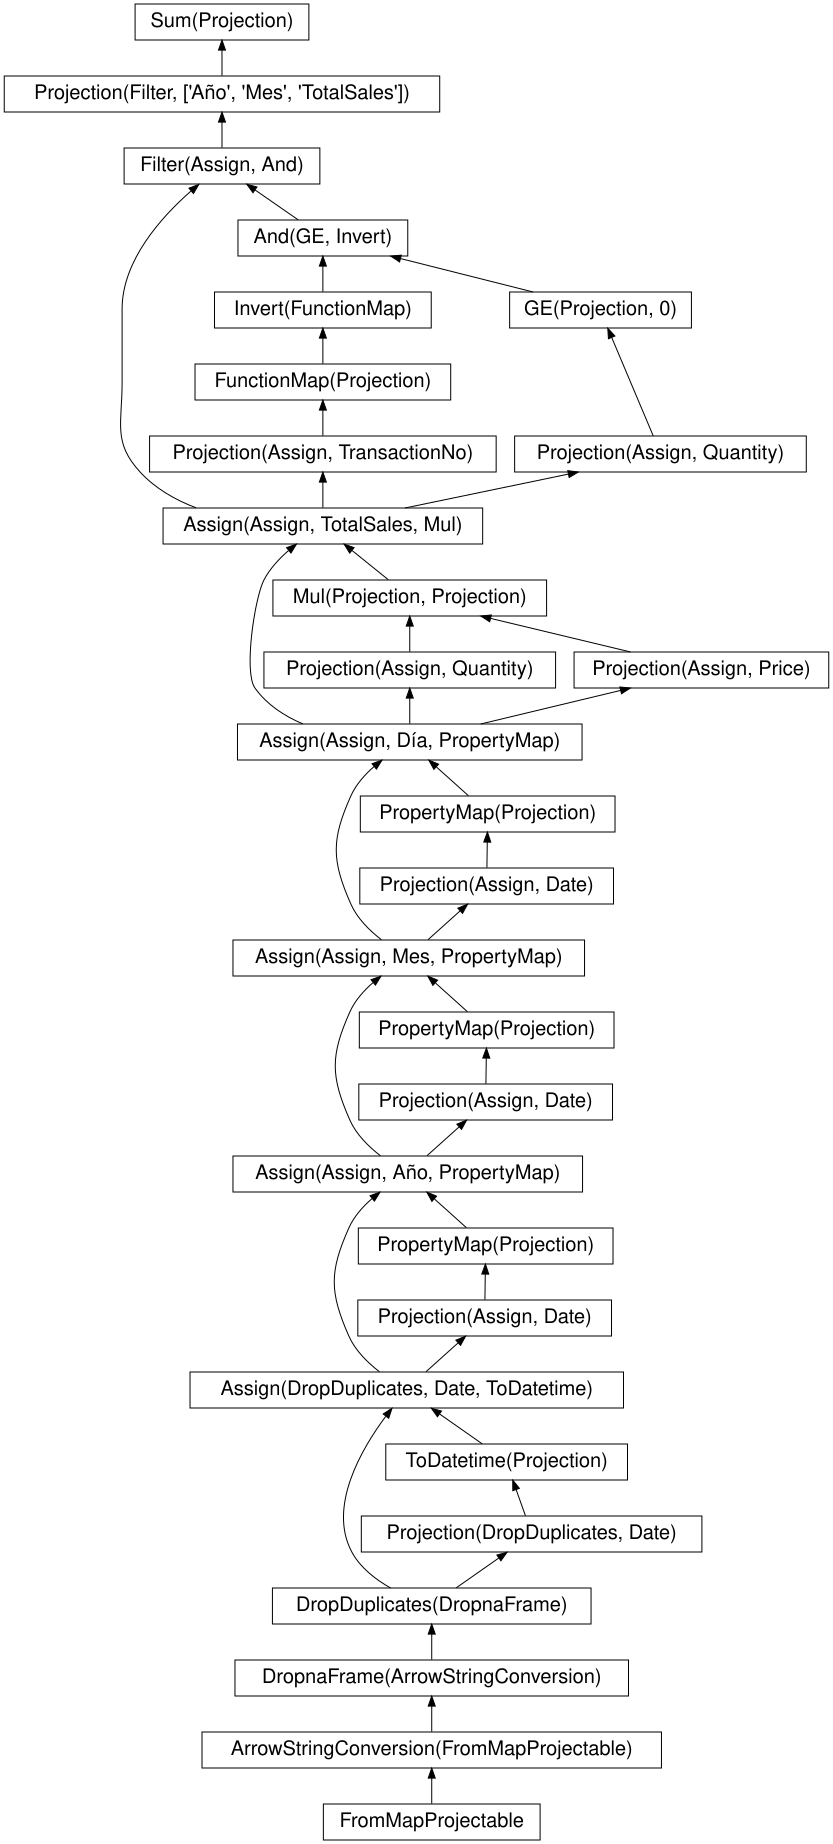

In [30]:
facturacion_mensual.visualize()

In [31]:
# Ejecutamos el resultado
facturacion_mensual_result = facturacion_mensual.compute()

facturacion_mensual_result

Año   Mes
2019  8      4749801.23
      9      6613772.79
      4      3579310.06
      6      4486050.15
      12     2512069.52
2018  12     4397648.39
2019  1      4548423.47
      5      4569952.21
      11     7828489.53
      7      4571494.88
      10     7212279.85
      2      3327342.64
      3      4384669.82
Name: TotalSales, dtype: float64

In [32]:
# Lo convertimos a un dataframe
facturacion_mensual_resultado = (facturacion_mensual_result.reset_index().sort_values(["Año", "Mes"]))

facturacion_mensual_resultado

,Año,Mes,TotalSales
5,2018,12,4397648.39
6,2019,1,4548423.47
11,2019,2,3327342.64
12,2019,3,4384669.82
2,2019,4,3579310.06
7,2019,5,4569952.21
3,2019,6,4486050.15
9,2019,7,4571494.88
0,2019,8,4749801.23
1,2019,9,6613772.79


### Consulta 7 : Ingresos por país
Rubro: Agregación

In [33]:
ingreso_por_pais = (ddf.groupby("Country")["TotalSales"].sum().compute().sort_values(ascending=False))

In [34]:
ingreso_por_pais

Country
United Kingdom          52346795.60
Netherlands              2151553.59
EIRE                     1711819.39
Germany                  1369839.62
France                   1329903.39
Australia                 995414.01
Sweden                    401879.89
Switzerland               361691.96
Japan                     293155.44
Spain                     280843.80
Belgium                   272131.88
Norway                    188612.52
Portugal                  175959.28
Finland                   120972.15
Denmark                   101083.99
Channel Islands            95932.24
Italy                      78536.24
Austria                    69147.26
Singapore                  63480.95
Cyprus                     61614.64
Israel                     54722.14
Iceland                    38307.42
USA                        32846.41
Unspecified                32638.74
Canada                     30398.67
Hong Kong                  27006.66
Poland                     19793.11
Malta               

In [35]:
# Convertimos a un dataframe

top_10_countries = (ingreso_por_pais.head(10).reset_index())

top_10_countries.columns = ["Country","TotalSales"]

top_10_countries

,Country,TotalSales
0,United Kingdom,52346795.60
1,Netherlands,2151553.59
2,EIRE,1711819.39
3,Germany,1369839.62
4,France,1329903.39
5,Australia,995414.01
6,Sweden,401879.89
7,Switzerland,361691.96
8,Japan,293155.44
9,Spain,280843.80


### Consulta 8 : Top 10 productos por unidades vendidas
Rubro : Agrupación y ordenamiento

In [36]:
product_sales = (ddf.groupby(["ProductNo", "ProductName"])["Quantity"].sum().compute())

In [37]:
top_10_products = (product_sales.sort_values(ascending=False).head(10).reset_index())

top_10_products

,ProductNo,ProductName,Quantity
0,23843,Paper Craft Little Birdie,80995.0
1,23166,Medium Ceramic Top Storage Jar,78033.0
2,22197,Popcorn Holder,56902.0
3,84077,World War 2 Gliders Asstd Designs,54951.0
4,85099B,Jumbo Bag Red Retrospot,48375.0
5,85123A,Cream Hanging Heart T-Light Holder,37937.0
6,21212,Pack Of 72 Retrospot Cake Cases,36492.0
7,84879,Assorted Colour Bird Ornament,36394.0
8,23084,Rabbit Night Light,30742.0
9,22492,Mini Paint Set Vintage,26633.0


### Consulta 9 : Top 10 clientes por gastos
Rubro : Agrupación, agregación y ordenamiento

In [38]:
customer_sales = (ddf.groupby("CustomerNo")["TotalSales"].sum().compute())

In [39]:
top_10_customers = (customer_sales.sort_values(ascending=False).head(10).reset_index())

top_10_customers

,CustomerNo,TotalSales
0,14646,2112282.03
1,16446,1002741.57
2,14911,914204.19
3,12415,900545.54
4,18102,897137.36
5,17450,891069.53
6,12346,840113.80
7,14156,694202.51
8,13694,646116.78
9,17511,639006.19


### Consulta 10 : Estadísticos descriptivos
Rubro : Cálculo de métricas

In [40]:
estadisticas_numericas = ddf[["Price", "Quantity", "TotalSales"]].describe()

In [41]:
estadisticas_numericas

,Price,Quantity,TotalSales
npartitions=1,,,
,float64,float64,float64
,...,...,...


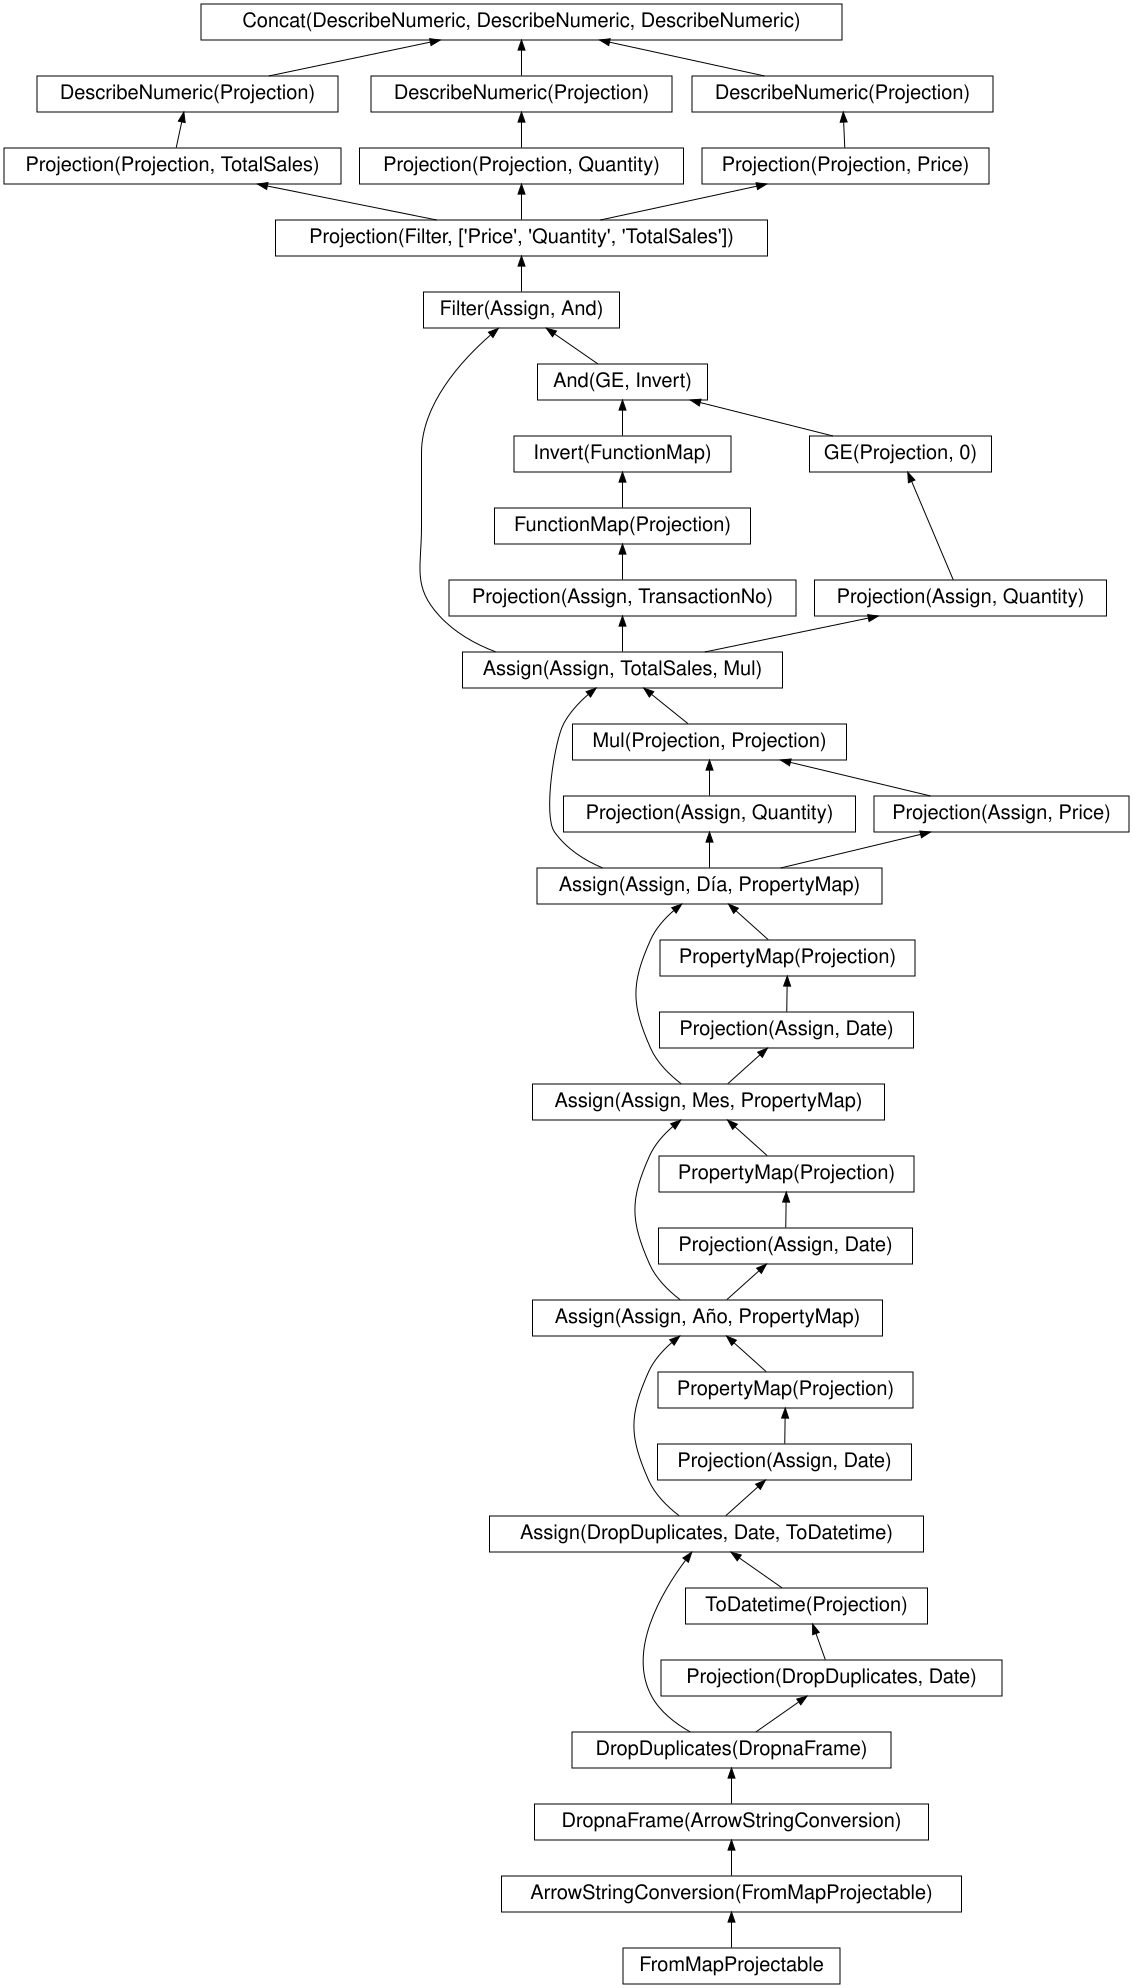

In [42]:
estadisticas_numericas.visualize()

In [43]:
estadisticas_numericas = estadisticas_numericas.compute()

In [44]:
estadisticas_numericas

,Price,Quantity,TotalSales
count,522601.000000,522601.000000,5.226010e+05
mean,12.637160,10.667492,1.201324e+02
std,7.965974,157.542420,1.860159e+03
min,5.130000,1.000000,5.130000e+00
25%,11.100000,1.000000,1.857000e+01
50%,11.940000,4.000000,4.596000e+01
75%,14.090000,12.000000,1.277000e+02
max,660.620000,80995.000000,1.002718e+06


In [45]:
# Si buscamos solo la mediana

median_values = ddf[["Price", "Quantity", "TotalSales"]].quantile(0.5)

In [46]:
median_values

Dask Series Structure:
npartitions=1
Price         float64
TotalSales        ...
Dask Name: fromscalars, 35 expressions
Expr=FromScalars(2f82753)

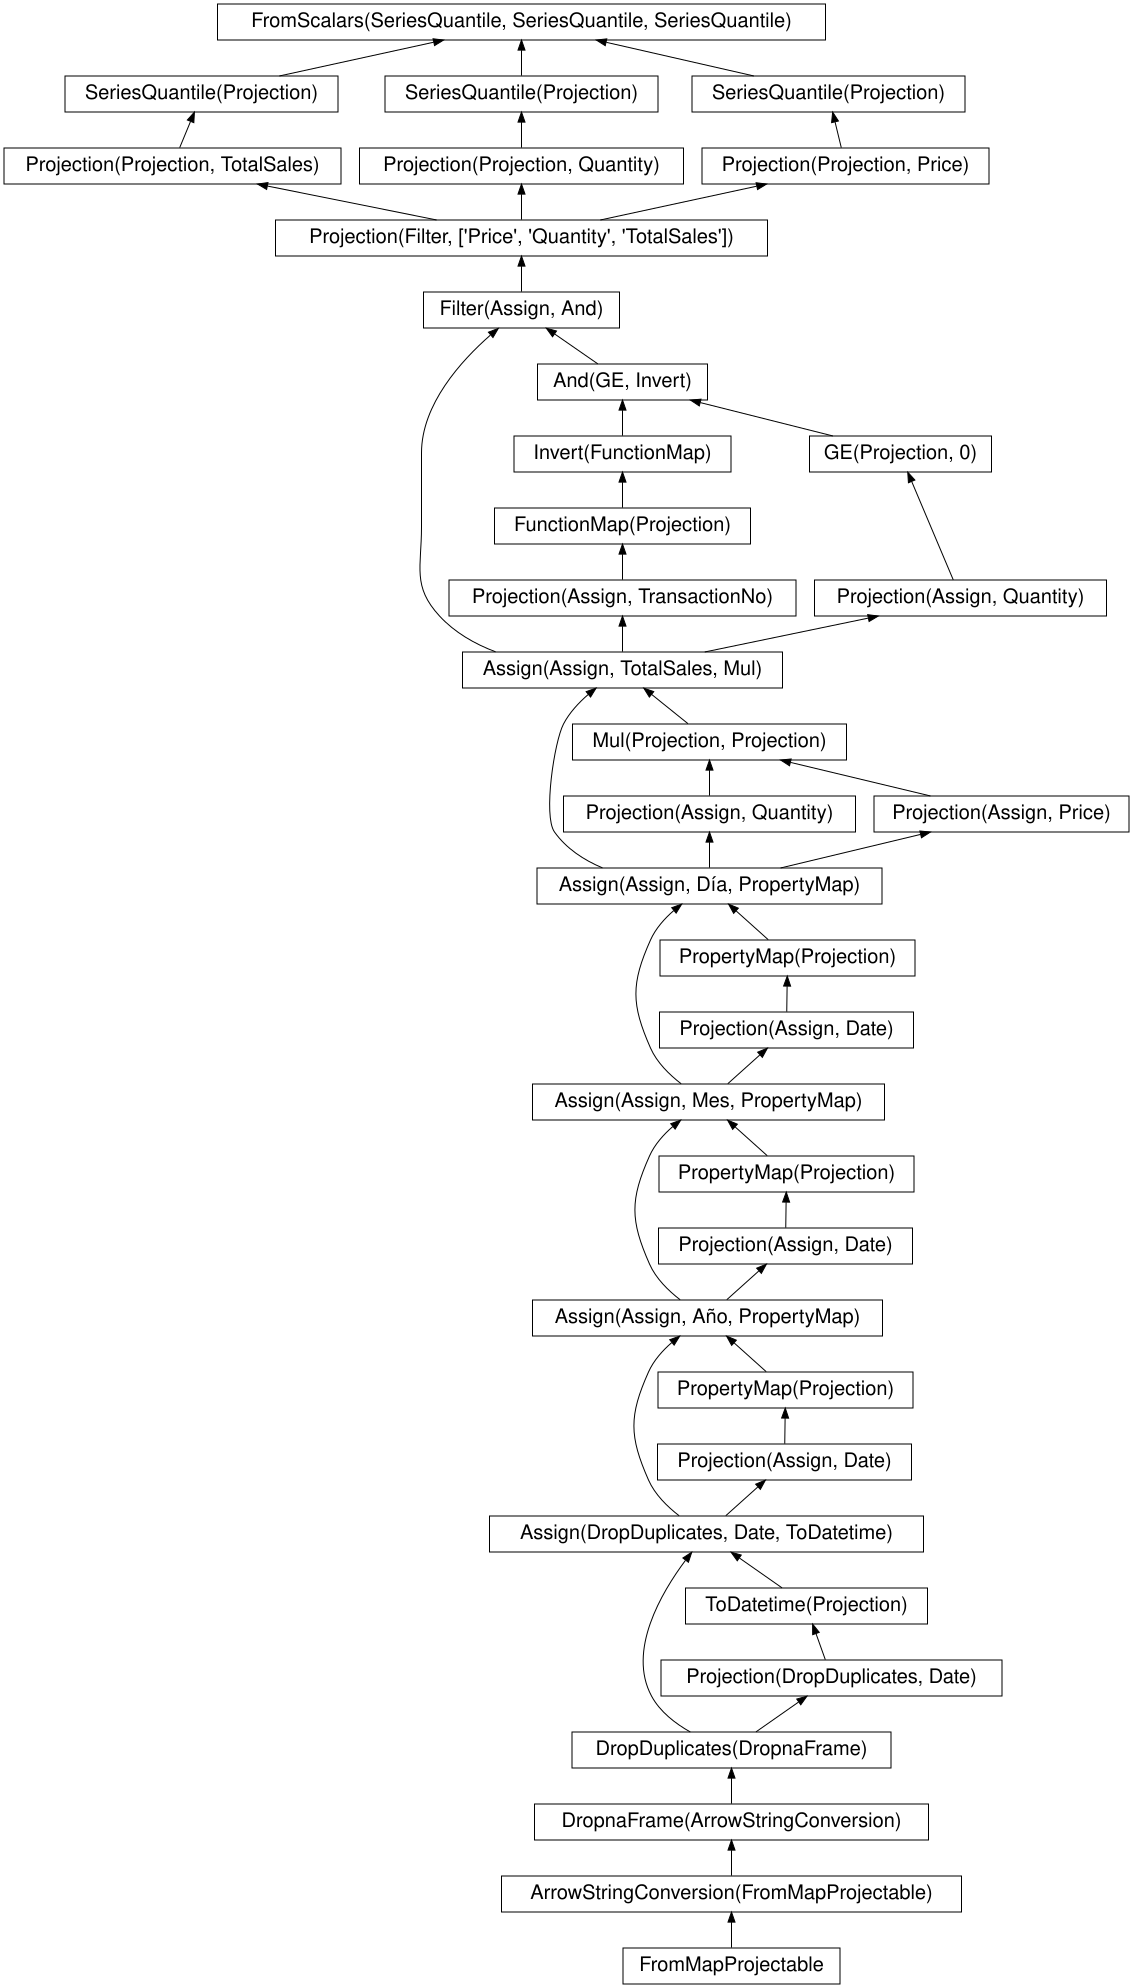

In [47]:
median_values.visualize()

In [48]:
median_values = median_values.compute()

In [49]:
median_values

Price         11.94
Quantity       4.00
TotalSales    45.96
Name: 0.5, dtype: float64

In [50]:
# Podemos hacer esto con los demas resultados

mean_values = ddf[["Price", "Quantity", "TotalSales"]].mean().compute()

min_values = ddf[["Price", "Quantity", "TotalSales"]].min().compute()

max_values = ddf[["Price", "Quantity", "TotalSales"]].max().compute()

std_values = ddf[["Price", "Quantity", "TotalSales"]].std().compute()

In [51]:
# Y en un DataFrame los juntamos

numeric_stats = pd.DataFrame({
    "Media": mean_values,
    "Mediana": median_values,
    "Mínimo": min_values,
    "Máximo": max_values,
    "Desviación estándar": std_values
})

numeric_stats

,Media,Mediana,Mínimo,Máximo,Desviación estándar
Price,12.637160,11.94,5.13,660.62,7.965974
Quantity,10.667492,4.00,1.00,80995.00,157.542420
TotalSales,120.132385,45.96,5.13,1002718.10,1860.158603
